# TextSense AI - Intelligent Text Analytics & Predictor

## 1. Import Libraries

In [18]:
import pandas as pd

In [19]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [20]:
print(os.listdir("/kaggle/input/datasets"))

['uciml']


In [21]:
print(os.listdir("/kaggle/input/datasets/uciml"))

['sms-spam-collection-dataset']


In [22]:
print(os.listdir("/kaggle/input/datasets/uciml/sms-spam-collection-dataset"))

['spam.csv']


## 2. Load Dataset

In [23]:
df = pd.read_csv(
    "/kaggle/input/datasets/uciml/sms-spam-collection-dataset/spam.csv",
    encoding="latin-1"
)

In [24]:
print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [25]:
print(df.shape)

(5572, 5)


In [26]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [27]:
df = df[["v1", "v2"]]

df.columns = ["label", "message"]

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


## 3. Data Cleaning

The original dataset contains unused columns and is reduced to the two required columns:

- **label** — HAM or SPAM
- **message** — SMS text

Basic dataset information, class distribution and missing values are checked before further processing.

In [28]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


In [29]:
print(df["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [30]:
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [31]:
df = df.copy()

df["message_length"] = df["message"].apply(len)

In [32]:
print(df[["message", "message_length"]].head())

                                             message  message_length
0  Go until jurong point, crazy.. Available only ...             111
1                      Ok lar... Joking wif u oni...              29
2  Free entry in 2 a wkly comp to win FA Cup fina...             155
3  U dun say so early hor... U c already then say...              49
4  Nah I don't think he goes to usf, he lives aro...              61


In [33]:
print(df.groupby("label")["message_length"].mean())

label
ham      71.023627
spam    138.866131
Name: message_length, dtype: float64


In [34]:
print(df.duplicated().sum())

403


## 4. Exploratory Data Analysis

Exploratory Data Analysis was performed to understand the dataset structure, class distribution and message-length patterns.

The dataset contains substantially more HAM messages than SPAM messages.

Message length was also examined to understand whether spam messages tend to differ in length from normal messages.

In [35]:
print("Class Distribution:")
print(df["label"].value_counts())

print("\nAverage Message Length:")
print(df.groupby("label")["message_length"].mean())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Average Message Length:
label
ham      71.023627
spam    138.866131
Name: message_length, dtype: float64

Duplicate Records:
403


## 5. Duplicate Removal

In [36]:
print(df[df.duplicated()].head())

    label                                            message  message_length
102   ham  As per your request 'Melle Melle (Oru Minnamin...             160
153   ham  As per your request 'Melle Melle (Oru Minnamin...             160
206   ham  As I entered my cabin my PA said, '' Happy B'd...             156
222   ham                             Sorry, I'll call later              22
325   ham                   No calls..messages..missed calls              32


In [37]:
df = df.drop_duplicates()

In [38]:
print(df.shape)

(5169, 3)


In [39]:
print(df.duplicated().sum())

0


### After Duplicate Removal

After removing duplicate records:

- **Total messages:** 5,169
- **HAM messages:** 4,516
- **SPAM messages:** 653
- **Duplicates remaining:** 0

## 6. Label Encoding

Machine learning models require numerical target labels.

The SMS labels are encoded as:

- **HAM = 0**
- **SPAM = 1**

In [40]:
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [41]:
print(df[["label", "label_num"]].head())

  label  label_num
0   ham          0
1   ham          0
2  spam          1
3   ham          0
4   ham          0


In [42]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

In [43]:
print(clean_text("WIN a FREE prize!!!"))

win a free prize


In [44]:
df["clean_message"] = df["message"].apply(clean_text)

In [45]:
df["clean_message"] = ...

In [46]:
print(df[["message", "clean_message"]].head())

                                             message clean_message
0  Go until jurong point, crazy.. Available only ...      Ellipsis
1                      Ok lar... Joking wif u oni...      Ellipsis
2  Free entry in 2 a wkly comp to win FA Cup fina...      Ellipsis
3  U dun say so early hor... U c already then say...      Ellipsis
4  Nah I don't think he goes to usf, he lives aro...      Ellipsis


In [47]:
print(df["label"].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


In [48]:
print(df["label_num"].value_counts())

label_num
0    4516
1     653
Name: count, dtype: int64


## 7. Text Preprocessing

The SMS messages are cleaned before converting them into numerical features.

The preprocessing converts text to lowercase and removes non-alphabetic characters.

In [49]:
X = df["clean_message"]
y = df["label_num"]

print(X.head())
print(y.head())

0    Ellipsis
1    Ellipsis
2    Ellipsis
3    Ellipsis
4    Ellipsis
Name: clean_message, dtype: object
0    0
1    0
2    1
3    0
4    0
Name: label_num, dtype: int64


## 8. Train/Test Split

The cleaned dataset is divided into training and testing sets using an 80/20 split.

- **Training samples:** 4,135
- **Testing samples:** 1,034
- **Test size:** 20%
- **Random state:** 42
- **Stratification:** Used

Stratification helps maintain a similar HAM/SPAM class distribution in both sets.

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [53]:
print("Training labels:")
print(y_train.value_counts())

print("Testing labels:")
print(y_test.value_counts())

Training labels:
label_num
0    3613
1     522
Name: count, dtype: int64
Testing labels:
label_num
0    903
1    131
Name: count, dtype: int64


## 9. TF-IDF Vectorization

TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert SMS text into numerical features.

The baseline representation uses **unigrams**, meaning individual words are used as features.

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [55]:
vectorizer = TfidfVectorizer()

In [56]:
print(df["clean_message"].apply(type).value_counts())

clean_message
<class 'ellipsis'>    5169
Name: count, dtype: int64


In [57]:
df["clean_message"] = df["message"].apply(clean_text)

In [58]:
print(df["clean_message"].apply(type).value_counts())

clean_message
<class 'str'>    5169
Name: count, dtype: int64


In [59]:
X = df["clean_message"]
y = df["label_num"]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [61]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [62]:
X_test_tfidf = vectorizer.transform(X_test)

In [63]:
print(X_train_tfidf.shape)

(4135, 8164)


In [64]:
print(X_test_tfidf.shape)

(1034, 8164)


In [65]:
print(vectorizer.get_feature_names_out()[:20])

['008704050406' '0089my' '0121' '01223585236' '01223585334' '0125698789'
 '02' '020603' '0207' '02070836089' '02072069400' '020903' '050703' '0578'
 '06' '060505' '061104' '07090201529' '07090298926' '071104']


In [66]:
print(type(X_train_tfidf))

<class 'scipy.sparse._csr.csr_matrix'>


## 10. Naive Bayes Model

A Multinomial Naive Bayes classifier is trained using the TF-IDF features.

This model is used as a baseline machine learning approach for SMS spam classification.

In [67]:
from sklearn.naive_bayes import MultinomialNB

In [68]:
nb_model = MultinomialNB()

In [69]:
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [70]:
nb_predictions = nb_model.predict(X_test_tfidf)

In [71]:
print(nb_predictions[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [72]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9487427466150871


In [73]:
from sklearn.metrics import precision_score, recall_score, f1_score

nb_precision = precision_score(y_test, nb_predictions)
nb_recall = recall_score(y_test, nb_predictions)
nb_f1 = f1_score(y_test, nb_predictions)

print("Precision:", nb_precision)
print("Recall:", nb_recall)
print("F1-score:", nb_f1)

Precision: 1.0
Recall: 0.5954198473282443
F1-score: 0.7464114832535885


In [74]:
from sklearn.metrics import classification_report

print(classification_report(y_test, nb_predictions)) 

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       903
           1       1.00      0.60      0.75       131

    accuracy                           0.95      1034
   macro avg       0.97      0.80      0.86      1034
weighted avg       0.95      0.95      0.94      1034



In [75]:
from sklearn.metrics import confusion_matrix

nb_cm = confusion_matrix(y_test, nb_predictions)

print(nb_cm)

[[903   0]
 [ 53  78]]


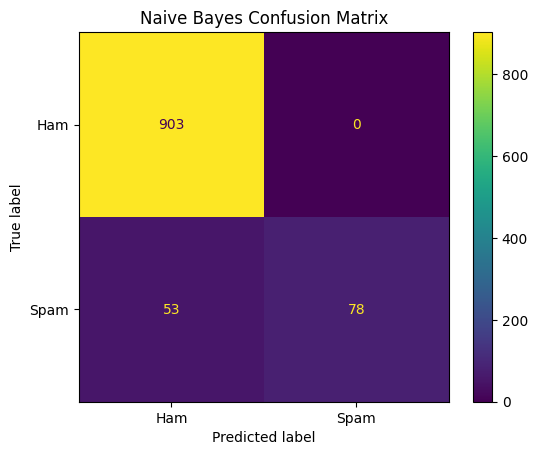

In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=nb_cm,
    display_labels=["Ham", "Spam"]
).plot()

plt.title("Naive Bayes Confusion Matrix")
plt.show()

## 11. Logistic Regression Model

Logistic Regression is trained using the same TF-IDF unigram features.

This provides a second model for comparison with Naive Bayes.

In [77]:
from sklearn.linear_model import LogisticRegression

In [78]:
lr_model = LogisticRegression(max_iter=1000)

In [79]:
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [80]:
lr_predictions = lr_model.predict(X_test_tfidf)

In [81]:
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1-score:", lr_f1)

Logistic Regression Accuracy: 0.9622823984526112
Precision: 0.9893617021276596
Recall: 0.7099236641221374
F1-score: 0.8266666666666667


In [82]:
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.99      0.71      0.83       131

    accuracy                           0.96      1034
   macro avg       0.97      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034



In [83]:
lr_cm = confusion_matrix(y_test, lr_predictions)

print(lr_cm)

[[902   1]
 [ 38  93]]


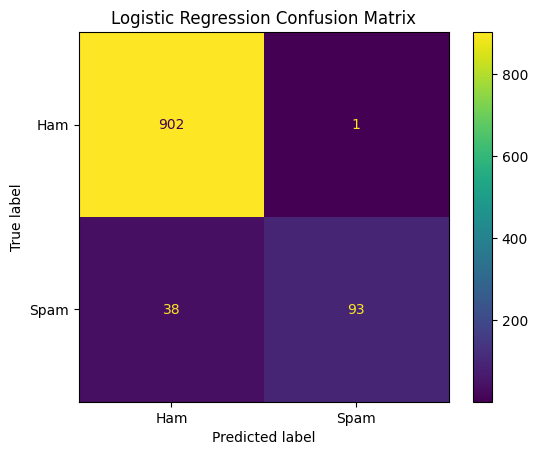

In [84]:
ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=["Ham", "Spam"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 12. Model Comparison

In [85]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [nb_accuracy, lr_accuracy],
    "Precision": [nb_precision, lr_precision],
    "Recall": [nb_recall, lr_recall],
    "F1-score": [nb_f1, lr_f1]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-score
0          Naive Bayes  0.948743   1.000000  0.595420  0.746411
1  Logistic Regression  0.962282   0.989362  0.709924  0.826667


## 13. Error Analysis

In [86]:
import pandas as pd

error_analysis = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "predicted": lr_predictions
})

errors = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
]

print("Total incorrect predictions:", len(errors))
print(errors)

Total incorrect predictions: 39
                                                message  actual  predicted
5537  want explicit sex in 30 secs ring 02073162414 ...       1          0
528   you will recieve your tone within the next 24h...       1          0
2828  send a logo 2 ur lover  2 names joined by a he...       1          0
1941  well done your 4 costa del sol holiday or 5000...       1          0
491   congrats 1 year special cinema pass for 2 is y...       1          0
3062  hi babe its jordan how r u im home from abroad...       1          0
1662  hi if ur lookin 4 saucy daytime fun wiv busty ...       1          0
1448  as a registered optin subscriber ur draw 4 100...       1          0
1960  guess what somebody you know secretly fancies ...       1          0
5540  asked 3mobile if 0870 chatlines inclu in free ...       1          0
4671  customer service announcement we recently trie...       1          0
1698  free msg sorry a service you ordered from 8130...       1     

In [87]:
false_negatives = error_analysis[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0)
]

false_positives = error_analysis[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1)
]

print("False Negatives:", len(false_negatives))
print("False Positives:", len(false_positives))

False Negatives: 38
False Positives: 1


In [88]:
print(false_negatives[["message"]].to_string(index=False))

                                                                                                                                                      message
                                                                      want explicit sex in 30 secs ring 02073162414 now costs 20pmin gsex pobox 2667 wc1n 3xx
                                               you will recieve your tone within the next 24hrs for terms and conditions please see channel u teletext pg 750
 send a logo 2 ur lover  2 names joined by a heart txt love name1 name2 mobno eg love adam eve 07123456789 to 87077 yahoo pobox36504w45wq txtno 4 no ads 150p
           well done your 4 costa del sol holiday or 5000 await collection call 09050090044 now toclaim sae tcs pobox334 stockport sk38xh cost150pm max10mins
         congrats 1 year special cinema pass for 2 is yours call 09061209465 now c suprman v matrix3 starwars3 etc all 4 free bx420ip45we 150pm dont miss out
              hi babe its jordan how r u im home fro

In [89]:
print(false_positives[["message"]].to_string(index=False))

              message
waiting for your call


### Error Analysis Findings

The baseline model produced:

- **Total incorrect predictions:** 39
- **False Negatives:** 38
- **False Positives:** 1

Common patterns observed among false negatives included:

- Abbreviations
- Unusual spelling
- Phone numbers and numeric codes
- Promotional wording
- Conversational-looking spam
- Short messages
- Variations of spam vocabulary

These patterns indicate that some spam messages can resemble normal conversations or use wording that is less strongly associated with spam.

### False Positive Example

One false positive was:

> "Waiting for your call"

The actual label was **HAM**, but the baseline model predicted it as **SPAM**.

## 14. TF-IDF Bigram Experiment

In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer

bigram_vectorizer = TfidfVectorizer(ngram_range=(1, 2))

X_train_bigram = bigram_vectorizer.fit_transform(X_train)
X_test_bigram = bigram_vectorizer.transform(X_test)

print("Training shape:", X_train_bigram.shape)
print("Testing shape:", X_test_bigram.shape)

Training shape: (4135, 42443)
Testing shape: (1034, 42443)


In [91]:
from sklearn.linear_model import LogisticRegression

lr_bigram_model = LogisticRegression(max_iter=1000)

lr_bigram_model.fit(X_train_bigram, y_train)

lr_bigram_predictions = lr_bigram_model.predict(X_test_bigram)

print("Experimental model trained successfully!")

Experimental model trained successfully!


In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

bigram_accuracy = accuracy_score(y_test, lr_bigram_predictions)
bigram_precision = precision_score(y_test, lr_bigram_predictions)
bigram_recall = recall_score(y_test, lr_bigram_predictions)
bigram_f1 = f1_score(y_test, lr_bigram_predictions)

print("EXPERIMENTAL MODEL: Logistic Regression + TF-IDF (1,2)")
print("-----------------------------------------------------")
print(f"Accuracy : {bigram_accuracy * 100:.2f}%")
print(f"Precision: {bigram_precision * 100:.2f}%")
print(f"Recall   : {bigram_recall * 100:.2f}%")
print(f"F1-score : {bigram_f1 * 100:.2f}%")

EXPERIMENTAL MODEL: Logistic Regression + TF-IDF (1,2)
-----------------------------------------------------
Accuracy : 95.55%
Precision: 98.85%
Recall   : 65.65%
F1-score : 78.90%


In [93]:
bigram_errors = (y_test != lr_bigram_predictions).sum()

print("Baseline errors     :", (y_test != lr_predictions).sum())
print("Experimental errors :", bigram_errors)

Baseline errors     : 39
Experimental errors : 46


In [94]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline TF-IDF (1,1)",
        "Experimental TF-IDF (1,2)"
    ],
    "Accuracy": [
        lr_accuracy,
        bigram_accuracy
    ],
    "Precision": [
        lr_precision,
        bigram_precision
    ],
    "Recall": [
        lr_recall,
        bigram_recall
    ],
    "F1-score": [
        lr_f1,
        bigram_f1
    ]
})

print(comparison)

                       Model  Accuracy  Precision    Recall  F1-score
0      Baseline TF-IDF (1,1)  0.962282   0.989362  0.709924  0.826667
1  Experimental TF-IDF (1,2)  0.955513   0.988506  0.656489  0.788991


### Experiment 1 — TF-IDF Unigrams + Bigrams

#### Result

- **Accuracy:** 95.55%
- **Precision:** 98.85%
- **Recall:** 66.56%
- **F1-score:** 78.90%

The bigram configuration performed worse than the unigram baseline across the main performance metrics. Therefore, the unigram representation was retained.

## 15. Decision Threshold Analysis

Different decision thresholds were evaluated using the baseline Logistic Regression model.

The purpose of this experiment was to understand the trade-off between precision and recall.

In [95]:
spam_probabilities = lr_model.predict_proba(X_test_tfidf)[:, 1]

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:

    threshold_predictions = (
        spam_probabilities >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        threshold_predictions
    )

    precision = precision_score(
        y_test,
        threshold_predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        threshold_predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        threshold_predictions,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        threshold_predictions
    ).ravel()

    threshold_results.append([
        threshold,
        accuracy,
        precision,
        recall,
        f1,
        fp,
        fn
    ])

In [96]:
threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "False Positives",
        "False Negatives"
    ]
)

print(threshold_df)

   Threshold  Accuracy  Precision    Recall  F1-score  False Positives  \
0       0.30  0.974855   0.948718  0.847328  0.895161                6   
1       0.35  0.972921   0.963964  0.816794  0.884298                4   
2       0.40  0.970986   0.980952  0.786260  0.872881                2   
3       0.45  0.967118   0.980198  0.755725  0.853448                2   
4       0.50  0.962282   0.989362  0.709924  0.826667                1   
5       0.55  0.959381   0.989011  0.687023  0.810811                1   
6       0.60  0.952611   0.988095  0.633588  0.772093                1   

   False Negatives  
0               20  
1               24  
2               28  
3               32  
4               38  
5               41  
6               48  


### Threshold Analysis Result

A threshold of **0.30** produced:

- **Accuracy:** 97.49%
- **Precision:** 94.87%
- **Recall:** 84.73%
- **F1-score:** 89.52%
- **False Positives:** 6
- **False Negatives:** 20

Although the lower threshold improved recall and F1-score, it increased false positives and reduced precision.

## 16. Hyperparameter Tuning

In [97]:
from sklearn.linear_model import LogisticRegression

lr_tuned_model = LogisticRegression(
    C=2.0,
    max_iter=1000
)

lr_tuned_model.fit(X_train_tfidf, y_train)

lr_tuned_predictions = lr_tuned_model.predict(X_test_tfidf)

print("Tuned Logistic Regression trained successfully.")

Tuned Logistic Regression trained successfully.


In [98]:
tuned_accuracy = accuracy_score(y_test, lr_tuned_predictions)
tuned_precision = precision_score(y_test, lr_tuned_predictions)
tuned_recall = recall_score(y_test, lr_tuned_predictions)
tuned_f1 = f1_score(y_test, lr_tuned_predictions)

print("TUNED LOGISTIC REGRESSION")
print("------------------------")
print(f"Accuracy : {tuned_accuracy * 100:.2f}%")
print(f"Precision: {tuned_precision * 100:.2f}%")
print(f"Recall   : {tuned_recall * 100:.2f}%")
print(f"F1-score : {tuned_f1 * 100:.2f}%")

TUNED LOGISTIC REGRESSION
------------------------
Accuracy : 97.29%
Precision: 99.05%
Recall   : 79.39%
F1-score : 88.14%


In [99]:
tuned_cm = confusion_matrix(y_test, lr_tuned_predictions)

print("TUNED MODEL CONFUSION MATRIX")
print("----------------------------")
print(tuned_cm)

tn, fp, fn, tp = tuned_cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

TUNED MODEL CONFUSION MATRIX
----------------------------
[[902   1]
 [ 27 104]]

True Negatives : 902
False Positives: 1
False Negatives: 27
True Positives : 104


### Experiment 2 — Logistic Regression Hyperparameter Tuning

The tuned Logistic Regression model used **C = 2.0**.

#### Result

- **Accuracy:** 97.29%
- **Precision:** 99.05%
- **Recall:** 79.39%
- **F1-score:** 88.14%
- **False Positives:** 1
- **False Negatives:** 27

This configuration improved the baseline model while maintaining only one false positive.

### Experiment Conclusion

The experiments showed that different configurations produce different precision-recall trade-offs.

The final model was selected based on the overall balance between precision, recall, F1-score and false positives rather than accuracy alone.

## 17. Final Model

The final selected model is a Logistic Regression classifier trained on TF-IDF unigram features.

- **Model:** Logistic Regression
- **TF-IDF:** Unigrams
- **C:** 2.0
- **Decision Threshold:** 0.50

In [100]:
final_model = lr_tuned_model

print("Final model set successfully.")
print("Model: Logistic Regression")
print("C:", final_model.C)
print("Threshold: 0.50")

Final model set successfully.
Model: Logistic Regression
C: 2.0
Threshold: 0.50


## 18. New Message Prediction

The final trained model can be used to classify new, unseen SMS messages as either **HAM** or **SPAM**.

The prediction process is:

1. Validate the input message.
2. Clean the message.
3. Transform it using the trained TF-IDF vectorizer.
4. Pass the transformed message to the final Logistic Regression model.
5. Predict HAM or SPAM.
6. Display the prediction probability.

The trained TF-IDF vectorizer and final model are reused without fitting them again on the new message.

In [101]:
def predict_message(message):
    if not message or not message.strip():
        print("Please enter a message.")
        return

    cleaned = clean_text(message)

    if not cleaned.strip():
        print("Please enter a meaningful message.")
        return

    tfidf_message = vectorizer.transform([cleaned])

    prediction = final_model.predict(tfidf_message)[0]
    probabilities = final_model.predict_proba(tfidf_message)[0]

    if prediction == 0:
        result = "HAM"
        probability = probabilities[0]
        label = "Ham"
    else:
        result = "SPAM"
        probability = probabilities[1]
        label = "Spam"

    print("Prediction:", result)
    print(f"{label} Probability: {probability * 100:.2f}%")

### New Message Testing

Several manually selected SMS messages are used to verify the behaviour of the final model on unseen messages.

In [102]:
test_messages = [
    "Hey, are you coming to college tomorrow?",
    "Congratulations! You have won a free prize! Call now!",
    "Can you send me the notes when you get home?",
    "URGENT! Claim your special reward today before it expires!",
    "What time should we meet at the bus stop?"
]

for message in test_messages:
    print("Message:", message)
    predict_message(message)
    print("-" * 60)

Message: Hey, are you coming to college tomorrow?
Prediction: HAM
Ham Probability: 97.00%
------------------------------------------------------------
Message: Congratulations! You have won a free prize! Call now!
Prediction: SPAM
Spam Probability: 96.33%
------------------------------------------------------------
Message: Can you send me the notes when you get home?
Prediction: HAM
Ham Probability: 98.87%
------------------------------------------------------------
Message: URGENT! Claim your special reward today before it expires!
Prediction: SPAM
Spam Probability: 58.52%
------------------------------------------------------------
Message: What time should we meet at the bus stop?
Prediction: HAM
Ham Probability: 95.18%
------------------------------------------------------------


## Dataset Information

### Original Dataset

The original SMS Spam Collection dataset contained:

- **Total messages:** 5,572
- **HAM messages:** 4,825
- **SPAM messages:** 747
- **Duplicate records:** 403

## Final Prediction Verification

The final Logistic Regression model with C=2.0 was tested using several new SMS messages to verify its prediction behaviour.

The final model correctly classified all five manually selected test messages.

The urgent reward message received a relatively lower SPAM probability of 58.52%, but it was still correctly classified as SPAM.

Model probability should be interpreted as the classifier's estimated confidence for its prediction and not as a guarantee that the prediction is correct.

## Final Results

The final selected model is:

- **Model:** Logistic Regression
- **TF-IDF Representation:** Unigrams
- **Hyperparameter:** C = 2.0
- **Decision Threshold:** 0.50

### Final Performance

| Metric | Result |
|---|---:|
| Accuracy | 97.29% |
| Precision | 99.05% |
| Recall | 79.39% |
| F1-score | 88.14% |
| False Positives | 1 |
| False Negatives | 27 |

### Confusion Matrix

The final model produced the following confusion matrix:

```text
[[902, 1],
 [27, 104]]
```